/opt/conda/envs/vlma3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/vlma3/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 4/4 [00:02<00:00,  1.71it/s]



>>> Processing Clean Video...


/opt/conda/envs/vlma3/lib/python3.10/site-packages/torch/nn/modules/module.py:1623: UserWarning: For backward hooks to be called, module output should be a Tensor or a tuple of Tensors but received <class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
  warnings.warn("For backward hooks to be called,"


Full Answer: A few clouds are moving slowly through the sky above the winding river.


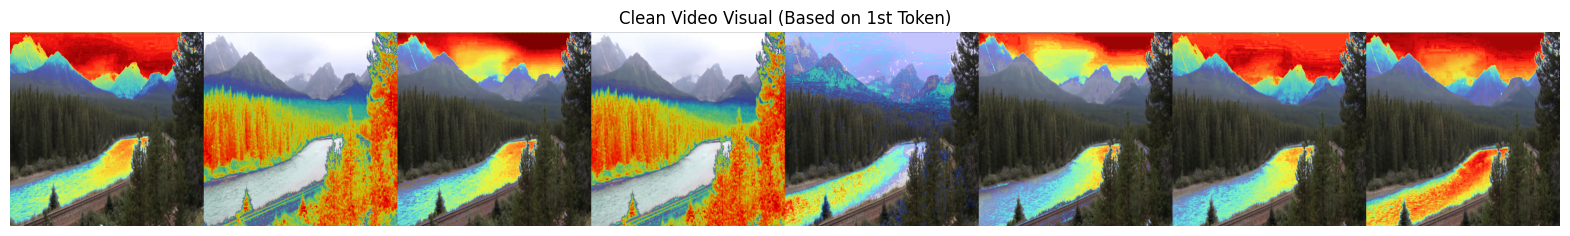


>>> Processing Target Video...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000244140625].


Full Answer: A large bird, possibly an eagle, is seen soaring through the sky.


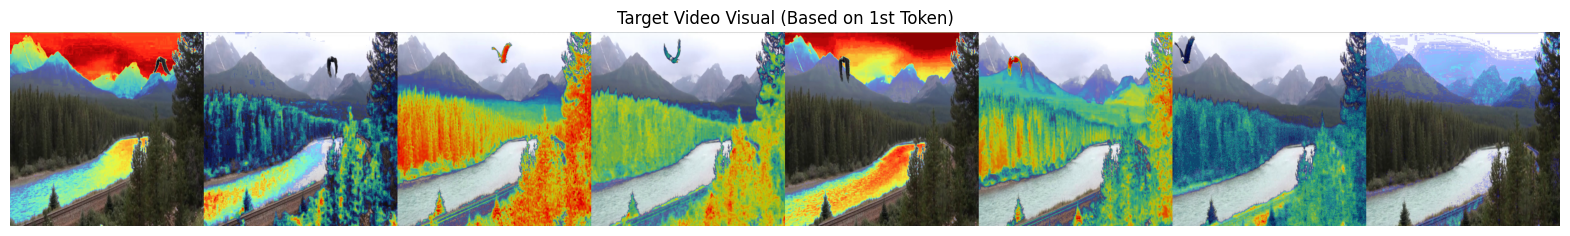


>>> Processing Adversarial Video...


/tmp/ipykernel_31823/830013446.py:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  attack_tensor = torch.load(path, map_location='cpu').squeeze(0)
Clipping input data to th

Full Answer: A large bird is soaring through the sky above the winding river.


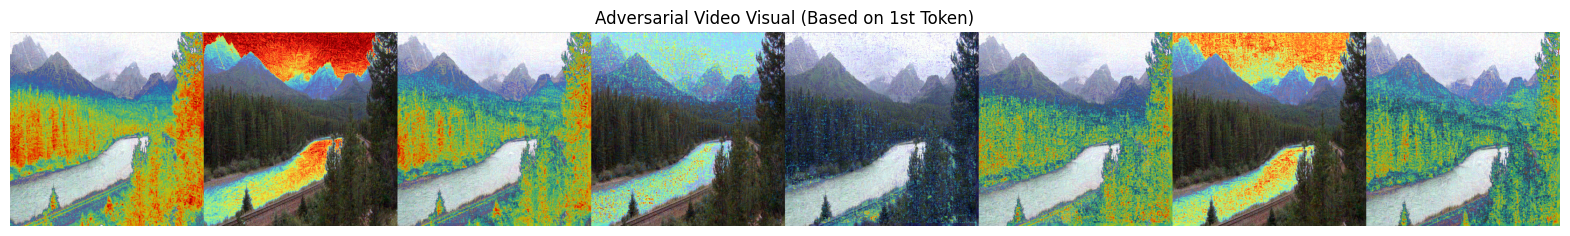

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TRANSFORMERS_CACHE"] = "/home/disk1/huggingface_cache/"
os.makedirs(os.environ["TRANSFORMERS_CACHE"], exist_ok=True)

import os
import re
import json
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image
from collections import defaultdict
from pathlib import Path
from transformers.image_transforms import resize
from transformers import LlavaOnevisionProcessor, LlavaOnevisionForConditionalGeneration
import gc

# --- Utility Functions ---

def load_video(video_path, num_segments=8):
    if not os.path.exists(video_path):
        raise ValueError(f"Path does not exist: {video_path}")

    frames_list = []
    if os.path.isdir(video_path):
        image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp')
        all_image_files = [os.path.join(video_path, f) for f in os.listdir(video_path) 
                          if f.lower().endswith(image_extensions)]

        if not all_image_files:
            raise ValueError(f"No images found in: {video_path}")

        def numerical_sort_key(value):
            parts = re.findall(r'(\d+)', value)
            return [int(part) for part in parts]

        all_image_files.sort(key=numerical_sort_key)
        total_frames = len(all_image_files)
        indices = np.linspace(0, total_frames - 1, min(total_frames, num_segments)).astype(int)

        for idx in indices:
            try:
                with Image.open(all_image_files[idx]) as pil_img:
                    if pil_img.mode != 'RGB':
                        pil_img = pil_img.convert('RGB')
                    frames_list.append(np.array(pil_img))
            except Exception as e:
                print(f"Warning: Could not read {all_image_files[idx]}: {e}")
                continue
    else:
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        indices = np.linspace(0, total_frames - 1, min(total_frames, num_segments)).astype(int)
        for target_idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
            ret, frame = cap.read()
            if ret:
                frames_list.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()

    return np.array(frames_list)

def pre_process_video(images: np.ndarray, size=(384, 384)):
    images = [resize(image=image, size=size) for image in images]
    return np.stack(images, axis=0)

def denormalize(tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    denorm_tensor = torch.squeeze(tensor.clone(), dim=0)
    mean = torch.tensor(mean, device=denorm_tensor.device, dtype=denorm_tensor.dtype).view(-1, 1, 1)
    std = torch.tensor(std, device=denorm_tensor.device, dtype=denorm_tensor.dtype).view(-1, 1, 1)
    if denorm_tensor.dim() == 4:
        mean = mean.unsqueeze(0)
        std = std.unsqueeze(0)
    denorm_tensor.mul_(std).add_(mean)
    return denorm_tensor

def tensor_to_numpy(tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    denormalized_tensor = denormalize(tensor.cpu().to(torch.float32), mean, std)
    np_image = denormalized_tensor.numpy()
    np_image = np.transpose(np_image, (1, 2, 0))
    return (np_image * 255).astype(np.uint8)

def load_attack_video(path):
    attack_tensor = torch.load(path, map_location='cpu').squeeze(0)
    attack_numpy = np.stack([tensor_to_numpy(t) for t in attack_tensor], axis=0)
    return attack_numpy

def get_question(question_path, video_name):
    with open(question_path) as f:
        meta_question = json.load(f)
    for item in meta_question:
        if item['video_name'] == video_name:
            return item['question']
    return "Describe the video."

# --- GradCAM Core ---

class VideoGradCAM:
    def __init__(self, model, processor):
        self.model = model
        self.processor = processor
        self.hooks = []
        self.gradients = {}
        self.activations = {}

    def register_hooks(self):
        def get_activation(name):
            def hook(module, input, output):
                if hasattr(output, 'last_hidden_state'):
                    self.activations[name] = output.last_hidden_state.detach()
                else:
                    self.activations[name] = output.detach()
            return hook

        def get_gradient(name):
            def hook(module, grad_input, grad_output):
                if grad_output[0] is not None:
                    self.gradients[name] = grad_output[0].detach()
            return hook

        h1 = self.model.vision_tower.register_forward_hook(get_activation('vision'))
        h2 = self.model.vision_tower.register_full_backward_hook(get_gradient('vision'))
        self.hooks.extend([h1, h2])

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
        self.gradients = {}
        self.activations = {}

    def compute_video_gradcam(self, video, question):
        self.register_hooks()
        try:
            conversation = [{"role": "user", "content": [{"type": "text", "text": question}, {"type": "video"}]}]
            prompt = self.processor.apply_chat_template(conversation, add_generation_prompt=True)
            
            video_tensor = torch.from_numpy(video).float() if isinstance(video, np.ndarray) else video
            if video_tensor.shape[-1] == 3:
                video_tensor = video_tensor.permute(0, 3, 1, 2)

            inputs = self.processor(text=prompt, videos=[video_tensor], return_tensors="pt").to(self.model.device, self.model.dtype)
            inputs['pixel_values_videos'].requires_grad_(True)

            # Deterministic Generation (temperature=0 / greedy)
            with torch.no_grad():
                outputs_gen = self.model.generate(
                    **inputs, 
                    max_new_tokens=200, 
                    do_sample=False,  # Greedy search
                    pad_token_id=self.processor.tokenizer.eos_token_id
                )
            
            input_len = inputs['input_ids'].shape[1]
            # Extract full answer
            full_answer_ids = outputs_gen[0, input_len:]
            full_answer_text = self.processor.tokenizer.decode(full_answer_ids, skip_special_tokens=True)
            
            # Extract the first token ID for GradCAM calculation
            first_token_id = full_answer_ids[0].item()

            # Forward pass for GradCAM (only for the first generated token position)
            outputs = self.model(**inputs, num_logits_to_keep=1)
            logits = outputs.logits
            target_logit = logits[0, -1, first_token_id]
            
            self.model.zero_grad()
            target_logit.backward()
            
            grads = inputs['pixel_values_videos'].grad.detach().cpu()
            acts = inputs['pixel_values_videos'].detach().cpu()
            
            # GradCAM: Weighted combination of activations
            weights = torch.mean(grads, dim=(3, 4), keepdim=True)
            cam = F.relu((weights * acts).sum(dim=2)).squeeze(0)
            
            # Normalization
            cam_min, cam_max = cam.min(), cam.max()
            if cam_max > cam_min:
                cam = (cam - cam_min) / (cam_max - cam_min)

            return cam, full_answer_text

        finally:
            self.remove_hooks()
            torch.cuda.empty_cache()

# --- Visualization ---

def get_attention_map(img, att_map, overlap=True):
    att_map = cv2.resize(att_map, (img.shape[1], img.shape[0]))
    norm_att = (att_map - att_map.min()) / (att_map.max() - att_map.min() + 1e-8)
    cmap = plt.get_cmap("jet")
    att_color = cmap(norm_att)[:, :, :3]
    if overlap:
        return (1 - norm_att[:, :, None]**0.7) * img + (norm_att[:, :, None]**0.7) * att_color
    return att_color

def visualize_and_print(gradcam_maps, original_video, title="GradCAM Result"):
    if isinstance(gradcam_maps, torch.Tensor):
        gradcam_maps = gradcam_maps.numpy()
    num_frames = gradcam_maps.shape[0]
    overlays = []
    for i in range(num_frames):
        img = original_video[i].astype(np.float32) / 255.0 if original_video[i].max() > 1.0 else original_video[i]
        overlay = get_attention_map(img, gradcam_maps[i])
        overlays.append(overlay)
    concat_img = np.concatenate(overlays, axis=1)
    plt.figure(figsize=(20, 5))
    plt.imshow(concat_img)
    plt.title(title, fontsize=12)
    plt.axis('off')
    plt.show()

# --- Execution ---

def main():
    model_id = "llava-hf/llava-onevision-qwen2-7b-ov-hf"
    model = LlavaOnevisionForConditionalGeneration.from_pretrained(
        model_id, torch_dtype=torch.float16, device_map='auto'
    )
    processor = LlavaOnevisionProcessor.from_pretrained(model_id)
    gradcam_engine = VideoGradCAM(model, processor)

    video_name = "1034a"
    question_path = "/home/disk1/Att_VLLM/Video-Sham/question.json"
    question = get_question(question_path, video_name)

    # Define tasks to loop through to save memory
    tasks = [
        ("Clean Video", f"/home/disk1/Att_VLLM/Video-Sham/clean/{video_name}/1", "loader"),
        ("Target Video", f"/home/disk1/Att_VLLM/Video-Sham/target/{video_name}", "loader"),
        ("Adversarial Video", "/home/disk1/Att_VLLM/LLaVA-OV/adv_video/1034a-8.pt", "torch")
    ]

    for label, path, mode in tasks:
        print(f"\n>>> Processing {label}...")
        if mode == "loader":
            current_video = pre_process_video(load_video(path))
        else:
            current_video = load_attack_video(path)

        cam_map, full_answer = gradcam_engine.compute_video_gradcam(current_video, question)
        print(f"Full Answer: {full_answer}")

        visualize_and_print(cam_map, current_video, title=f"{label} Visual (Based on 1st Token)")

        del current_video, cam_map
        gc.collect()
        torch.cuda.empty_cache()

if __name__ == "__main__":
    main()